In [1]:
%matplotlib inline
import pandas as pd

In [ ]:
df = pd.read_csv("data/requests.csv")
df.head()

,text,target_node,subject
0,"One afternoon, a pilot was flying a small airp...",2,professional_law
1,Which of the following statements expresses a ...,1,professional_psychology
2,An important source of information on the cred...,1,miscellaneous
3,The study of older adults and aging is referre...,1,human_aging
4,A lesion causing compression of the facial ner...,2,anatomy


In [2]:
# read the csv file runs/run_20260308_013725/results.csv in pandas
# df = pd.read_csv("runs/run_20260308_030610/results.csv", delimiter="|")
results_csv = "runs/run_20260308_030610/results.csv"

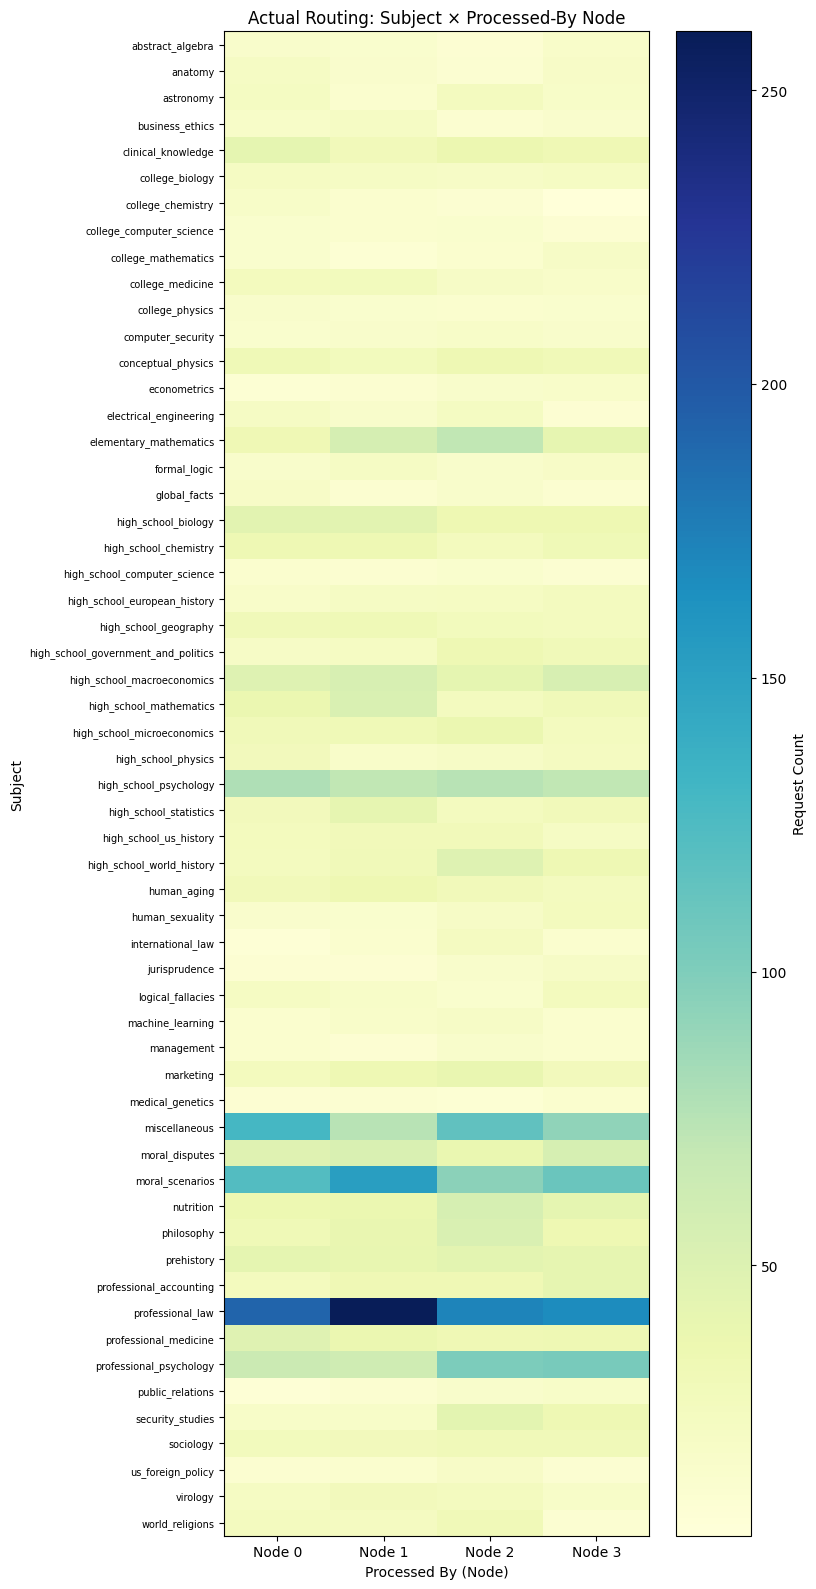

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Merge results with request subjects
df_results = pd.read_csv(results_csv, delimiter="|")

subjects = sorted(df_results["subject"].unique())
nodes = sorted(df_results["processed_by"].dropna().astype(int).unique())

# Build matrix: how many times each subject was processed by each node
matrix = np.zeros((len(subjects), len(nodes)), dtype=int)
subj_idx = {s: i for i, s in enumerate(subjects)}
node_idx = {n: i for i, n in enumerate(nodes)}

for _, row in df_results.dropna(subset=["processed_by"]).iterrows():
    si = subj_idx[row["subject"]]
    ni = node_idx[int(row["processed_by"])]
    matrix[si, ni] += 1

fig, ax = plt.subplots(figsize=(8, 16))
im = ax.imshow(matrix, aspect="auto", cmap="YlGnBu")

ax.set_xticks(range(len(nodes)))
ax.set_xticklabels([f"Node {n}" for n in nodes])
ax.set_yticks(range(len(subjects)))
ax.set_yticklabels(subjects, fontsize=7)
ax.set_xlabel("Processed By (Node)")
ax.set_ylabel("Subject")
ax.set_title("Actual Routing: Subject × Processed-By Node")

plt.colorbar(im, ax=ax, label="Request Count")
plt.tight_layout()
plt.show()

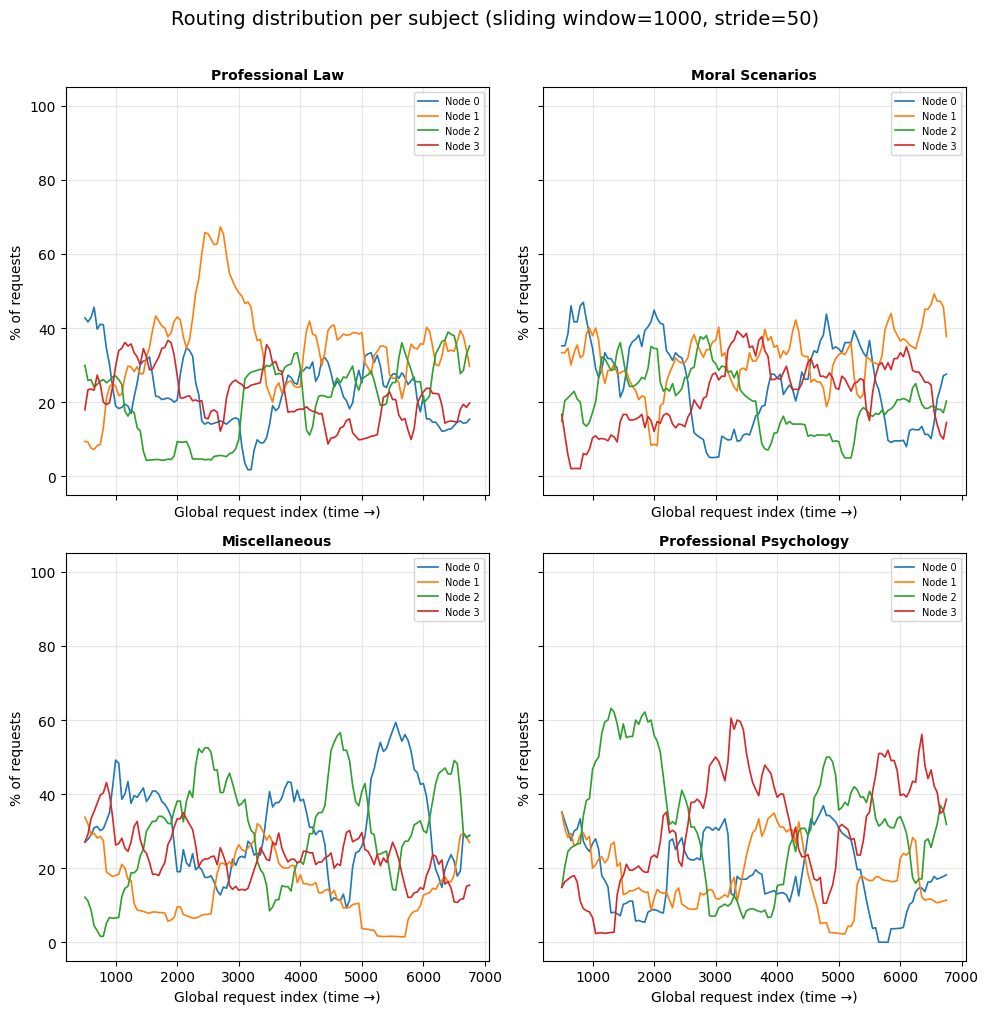

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv(results_csv, delimiter="|")
df = df.dropna(subset=["processed_by"])
df["processed_by"] = df["processed_by"].astype(int)

# Use request order as a proxy for time
df = df.sort_values("request_id").reset_index(drop=True)

window = 1000  # sliding window size
stride = 50   # step between windows
total_rows = len(df)
nodes = sorted(df["processed_by"].unique())

# Pick top-12 subjects by frequency
top_subjects = df["subject"].value_counts().head(4).index.tolist()

# Define sliding window positions
starts = list(range(0, total_rows - window + 1, stride))

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, subj in enumerate(top_subjects):
    ax = axes[idx]
    
    centers = []
    node_pcts = {n: [] for n in nodes}
    
    for start in starts:
        end = start + window
        chunk = df.iloc[start:end]
        sub_chunk = chunk[chunk["subject"] == subj]
        centers.append(start + window / 2)
        
        total = len(sub_chunk)
        if total > 0:
            counts = sub_chunk["processed_by"].value_counts()
            for n in nodes:
                node_pcts[n].append((counts.get(n, 0) / total) * 100)
        else:
            for n in nodes:
                node_pcts[n].append(np.nan)
    
    for n in nodes:
        ax.plot(centers, node_pcts[n], label=f"Node {n}", linewidth=1.2)
    
    ax.set_title(subj.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_ylim(-5, 105)
    ax.set_ylabel("% of requests")
    ax.set_xlabel("Global request index (time →)")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Routing distribution per subject (sliding window={window}, stride={stride})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [5]:
df = pd.read_csv(results_csv, delimiter="|")
# can you calculate averge latency for each node from total_time_s in df
df["total_time_s"] = df["total_time_s"].astype(float)
df["average_latency_s"] = df.groupby("target_node")["total_time_s"].transform("mean")

# print the average latency for each node
for node in nodes:
    print(f"Average latency for node {node}: {df[df['target_node'] == node]['average_latency_s'].mean()}")
print(f"Average latency across all nodes: {df["total_time_s"].mean()}")

Average latency for node 0: 2.4382498604131766
Average latency for node 1: 2.7418395911780524
Average latency for node 2: 3.6911961815163257
Average latency for node 3: 5.673723728813559
Average latency across all nodes: 3.638651866593467


In [6]:
# write the code for average cache hit ratio for each node from cache_hit_ratio in df
df["cache_hit_ratio"] = df["cache_hit_ratio"].astype(float)
df["average_cache_hit_ratio"] = df.groupby("target_node")["cache_hit_ratio"].transform("mean")

# print the average cache hit ratio for each node
for node in nodes:
    print(f"Average cache hit ratio for node {node}: {df[df['target_node'] == node]['average_cache_hit_ratio'].mean()}")
    

Average cache hit ratio for node 0: 0.24559229480737024
Average cache hit ratio for node 1: 0.2252050564819795
Average cache hit ratio for node 2: 0.2578322634200331
Average cache hit ratio for node 3: 0.24614084199015857


In [9]:
# print the throughput for each node from throughput in df. I have only latency in df   
total_requests = len(df)                                                                            
total_time = df["total_time_s"].sum()                                                               
                                                                                                    
print(f"Requests: {total_requests}")                                                                
print(f"Throughput: {total_requests / total_time:.2f} req/s")                                       
print(f"Avg latency: {df['total_time_s'].mean():.4f}s")
print(f"Token throughput: {(df['input_tokens'] + df['output_tokens']).sum() / total_time:.0f}tokens/s")                                                                                          
print(f"Avg cache hit: {df['cache_hit_ratio'].mean():.1%}")    

Requests: 7286
Throughput: 0.27 req/s
Avg latency: 3.6387s
Token throughput: 126tokens/s
Avg cache hit: 24.4%
